<a href="https://colab.research.google.com/github/HaydeePeruyero/honey-dashboard/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **BiotrAIn 2025 Tutorial: Data integration for microbiome research using scikit-bio**


# Section 04: Clustering (40 min)

- Time: 11:00 - 12:00:00 EDT, June 17, 2025
Welcome to the practical session 04. created by Víctor Muñiz, Nelly Selem (Secodment host), Jeanett Daga (Secodment).

🏆 QUESTIONS

1. How can we define and find groups on high dimensional data?
2. Given some vector representation of data, which are the main methodologies for cluster analysis?
3. What is the effect of different distance functions for clustering?

🎯 AIMS

1. To introduce the main methodologies for cluster analysis
2. To verify the impact of different low-dimensional representations of data in the cluster analysis
3. To present different visualizations of high-dimensional, sparse data and the clustering results.

🔑 KEY POINTS

Hierarchical clustering
K-means clustering
HDBSCAN
UMAP
Distance matrix

### Background

[Cluster analysis](https://en.wikipedia.org/wiki/Cluster_analysis) is an unsupervised machine learning technique used to group similar data points together based on their features or patterns. The goal is to divide a dataset into clusters (or segments) where objects within the same cluster are more alike to each other than to those in other clusters.

Clustering helps in discovering hidden structures and insights from unlabelled data.

In Chapter 3, we show that there are different ways to obtain a vector representation of the data, and we explore some reduction dimension techniques for these representations.
Here, we will use some clustering techniques that are suitable for data with those characteristics.

## Preparation ( 5 min - 11:00 am)

Install the latest version of scikit-bio if it hasn't been (needed for every Google Colab instance).

In [1]:
from importlib.util import find_spec

In [2]:
if find_spec('skbio') is None:
    !pip install -q scikit-bio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 31.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.2 MB/s eta 0:00:00


In [3]:
import skbio
skbio.__version__

'0.7.0'

We will be using different functions available in the script file ``aux_functions.py``. In order to use them, we need to load them from local drive by running the following code:

In [5]:
from google.colab import drive
import os
drive.mount('/content/drive/')
# woriking directory
os.chdir('/content/drive/My Drive/cabana/')

Mounted at /content/drive/


In [6]:
import pandas as pd
from skbio import Table
from skbio.diversity import beta_diversity



we are using the following data to make a Beta biodiversity analysis To compute and visualize beta diversity, you need:

1. Sample metadata (latam_samples.tsv): environmental metadata per sample.
2. feature table (latam_ogu.biom)counts of microbial taxa (OGUs) per sample.
3. Phylogenetic tree (latam_ogu.nwk)for UniFrac.
4. Taxonomy Taxonomy assignment file (latam_ogu.tax). for heatmaps

In [ ]:
from aux_functions import get_data

# Create a text variable to use after as a path to read files
#github_data = "https://raw.githubusercontent.com/nselem/biotraintemp/refs/heads/main/data/"
#data_path = "../1.Data/"
# data options:
#1 Latam Shotgun (default), loads the Latin America (filtered) dataset.
#2 EMP 500 Shotgun, loads the global dataset
#3 Latam Amplicon, loads the Latin America (filtered) 16S dataset.
#biom_df, metadata_df = get_data(data_path, data=1)

In [13]:
import skbio
from skbio import Table
from biom import load_table
from skbio.diversity import beta_diversity
#biom= Table.read(biom_path)
biom = load_table('../cabana/data/honey_Es_Shotgun_Mexico_hdf5.biom')
biom_df = biom.to_dataframe()
biom_df = biom_df.T
muestras_a_eliminar = [
    "SRR27931707", "SRR27931708", "SRR27931709",
    "SRR12632483", "SRR12632493"
]
biom_df = biom_df.drop(index=muestras_a_eliminar, errors='ignore')
biom_df

,3888,3911,3880,57577,3827,34305,3913,3917,3914,157791,...,2843777,1982112,1929964,1856642,1972568,2507503,1923406,1923598,3059727,2560285
SRR27931704,73794.0,55550.0,22797.0,19245.0,31136.0,69228.0,5313.0,30642.0,25735.0,23520.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931705,29239.0,24617.0,10918.0,7898.0,13701.0,66748.0,2263.0,11649.0,9504.0,9138.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931706,44589.0,37483.0,16439.0,12171.0,17985.0,160618.0,3350.0,16749.0,13164.0,12849.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931710,683.0,582.0,277.0,593.0,428.0,973.0,56.0,296.0,228.0,191.0,...,0,0,0,0,0,0,0,0,0,0
SRR27931711,1849.0,1687.0,907.0,2578.0,866.0,1104.0,99.0,988.0,592.0,723.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,42397.0,22699.0,10819.0,13289.0,24138.0,11807.0,2568.0,20230.0,15409.0,11838.0,...,0,0,0,0,0,0,0,0,0,0
90_Scapto,56250.0,24967.0,13609.0,12887.0,20627.0,14294.0,1874.0,16111.0,9005.0,9109.0,...,0,0,0,0,0,0,0,0,0,0
91_Scapto,45798.0,25574.0,11639.0,10340.0,21284.0,11970.0,2000.0,21006.0,11017.0,9479.0,...,0,0,0,0,0,0,0,0,0,0
92_Scapto,24452.0,15487.0,7215.0,4644.0,10751.0,5718.0,1033.0,7634.0,5593.0,5856.0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# metadata
# Read the TSV file directly from the URL into a pandas DataFrame
metadata_df = pd.read_csv('../cabana/data/metadata_Es_Shotgun_Mex_ordenado.csv', low_memory=False, index_col='sample_name')
valid_sample_names = biom_df.index.intersection(metadata_df.index)
valid_metadata_df = metadata_df.loc[valid_sample_names]
valid_metadata_df

,Assey_Type,AvgSpotLen,Bases,BioProject,BioSample,Size,Colection_Date,Consent,Experiment,ScientificName,...,Longitud,Model,LibraryName,LibrarySource,SRAStudy,Platform,ID,LibraryLayout,CenterName,Notas
SRR27931704,WGS,302,5697274998,PRJNA1074714,SAMN39880875,2036066464,18/10/2021,public,SRX23588786,honey,...,-3.599193,Illumina NovaSeq 6000,10,METAGENOMIC,SRP489180,ILLUMINA,H19,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931705,WGS,302,4395825628,PRJNA1074714,SAMN39880874,1561536444,18/10/2021,public,SRX23588785,honey,...,-3.599193,Illumina NovaSeq 6000,9,METAGENOMIC,SRP489180,ILLUMINA,H18,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931706,WGS,302,4966203364,PRJNA1074714,SAMN39880873,1773897028,18/10/2021,public,SRX23588784,honey,...,-3.599193,Illumina NovaSeq 6000,8,METAGENOMIC,SRP489180,ILLUMINA,H17,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931710,WGS,302,696696786,PRJNA1074714,SAMN39880928,243693766,18/10/2021,public,SRX23588780,honey,...,-5.968321,Illumina NovaSeq 6000,63,METAGENOMIC,SRP489180,ILLUMINA,H78,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
SRR27931711,WGS,302,1026133486,PRJNA1074714,SAMN39880927,345978931,18/10/2021,public,SRX23588779,honey,...,-5.968321,Illumina NovaSeq 6000,62,METAGENOMIC,SRP489180,ILLUMINA,H77,PAIRED,DAIRY RESEARCH INSTITUTE OF ASTURIAS- SPANISH ...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89_Scapto,WGS,not provided,10.795.256.666,PRJNA1235305,SAMN47325583,not provided,09/05/2022,non-public,not provided,honey metagenome,...,97.242417,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671093,PAIRED,not provided,NaN
90_Scapto,WGS,not provided,11.146.031.478,PRJNA1235305,SAMN47325585,not provided,09/05/2022,non-public,not provided,honey metagenome,...,97.242417,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671091,PAIRED,not provided,NaN
91_Scapto,WGS,not provided,11.330.001.422,PRJNA1235305,SAMN47325584,not provided,09/05/2022,non-public,not provided,honey metagenome,...,97.242417,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671092,PAIRED,not provided,NaN
92_Scapto,WGS,not provided,11.330.001.422,PRJNA1235305,SAMN47325586,not provided,11/05/2022,non-public,not provided,honey metagenome,...,96.936694,Illumina NovaSeq 6000,not provided,METAGENOMIC,SRP569975,ILLUMINA,SRR32671090,PAIRED,not provided,NaN


In [15]:
# labels for each sample
labels_data = valid_metadata_df['Specie']
labels_data

,Specie
SRR27931704,Spanish PDO
SRR27931705,Spanish PDO
SRR27931706,Spanish PDO
SRR27931710,Spanish PDO
SRR27931711,Spanish PDO
...,...
89_Scapto,Scaptotrigona mexicana
90_Scapto,Scaptotrigona mexicana
91_Scapto,Scaptotrigona mexicana
92_Scapto,Scaptotrigona mexicana


In [16]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from aux_functions import get_distance_matrix, get_tfidf, get_lsa, get_nmf, hierarchical_cluster

## Hierarchical clustering (10 min - 11:05 am)

Clustering algorithm which builds a tree-like structure (dendrogram) using agglomerative (bottom-up) or divisive (top-down) methods.

![Hierarchical agglomerative clustering](https://dashee87.github.io/images/hierarch.gif)

Figure 1. Hierarchical agglomerative clustering illustration.

We will use data based on two weighting schemes for gene occurrence: frecuency (`biom_df`) and inverse-frecuency (`biom_tfidf`).

In [40]:
from aux_functions import get_tfidf, hierarchical_cluster

tfidf_vect, tfidf = get_tfidf(biom_df)
biom_tfidf = pd.DataFrame(tfidf,columns=tfidf_vect.get_feature_names_out(),index=biom_df.index)

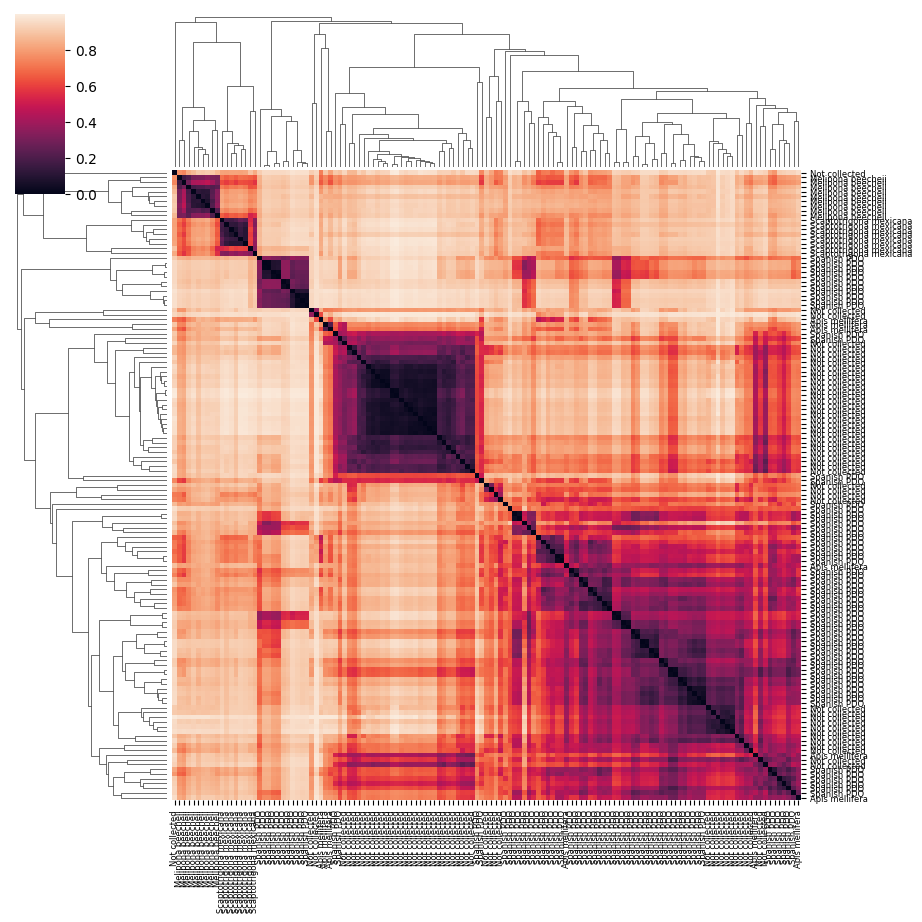

In [41]:
lk = 'average' #'single' 'complete' 'average' 'ward'
metric = 'braycurtis' #'euclidean' 'braycurtis' 'cosine'
hierarchical_cluster(biom_tfidf, link = lk, labels = labels_data,
                     plot_dist_matrix = True, metric_d = metric)

In [39]:
def hierarchical_cluster_modif1(X, link='ward', labels=None, plot_dist_matrix=True, metric_d='euclidean', palette=None):
    """
    Performs hierarchical clustering and shows a clustermap or dendrogram with colored tick backgrounds.
    """
    from scipy.cluster.hierarchy import linkage, dendrogram
    from scipy.spatial.distance import pdist, squareform
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    def get_distance_matrix(X, metric='euclidean'):
        return squareform(pdist(X, metric=metric))

    link_mat = linkage(X, method=link, metric=metric_d)

    if plot_dist_matrix:
        dd = get_distance_matrix(X, metric=metric_d)

        g = sns.clustermap(
            dd,
            row_linkage=link_mat,
            col_linkage=link_mat,
            xticklabels=labels,
            yticklabels=labels,
            figsize=(16, 14),      # Aumentar tamaño
            cmap="viridis"
        )

        row_inds = g.dendrogram_row.reordered_ind
        col_inds = g.dendrogram_col.reordered_ind
        row_labels = np.array(labels)[row_inds]
        col_labels = np.array(labels)[col_inds]
        ax = g.ax_heatmap

        # Quitar líneas de las ticks
        ax.tick_params(axis='both', length=0)

        # Etiquetas del eje y
        yticks = ax.get_yticklabels()
        for tick, label in zip(yticks, row_labels):
            color = palette.get(label, "#cccccc") if palette else "white"
            tick.set_backgroundcolor(color)
            tick.set_color("black")
            tick.set_fontsize(5)
            tick.set_bbox(dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.1'))

        # Etiquetas del eje x
        xticks = ax.get_xticklabels()
        for tick, label in zip(xticks, col_labels):
            color = palette.get(label, "#cccccc") if palette else "white"
            tick.set_rotation(90)
            tick.set_backgroundcolor(color)
            tick.set_color("black")
            tick.set_fontsize(5)
            tick.set_bbox(dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.1'))

        plt.suptitle(f"Clustermap - {link}, {metric_d}", y=1.05)
        plt.tight_layout()
        g.savefig("clustermap_colored_labels.png", dpi=300)
        g.savefig("clustermap_colored_labels.svg")
        plt.show()

    else:
        plt.figure(figsize=(10, 5))
        dendrogram(
            link_mat,
            orientation='top',
            labels=labels,
            distance_sort='descending',
            show_leaf_counts=True
        )
        plt.title('Hierarchical Clustering Dendrogram')
        plt.xlabel('Data Points')
        plt.ylabel('Distance')
        plt.tight_layout()
        plt.savefig("dendrogram_plot.png", dpi=300)
        plt.savefig("dendrogram_plot.svg")
        plt.show()


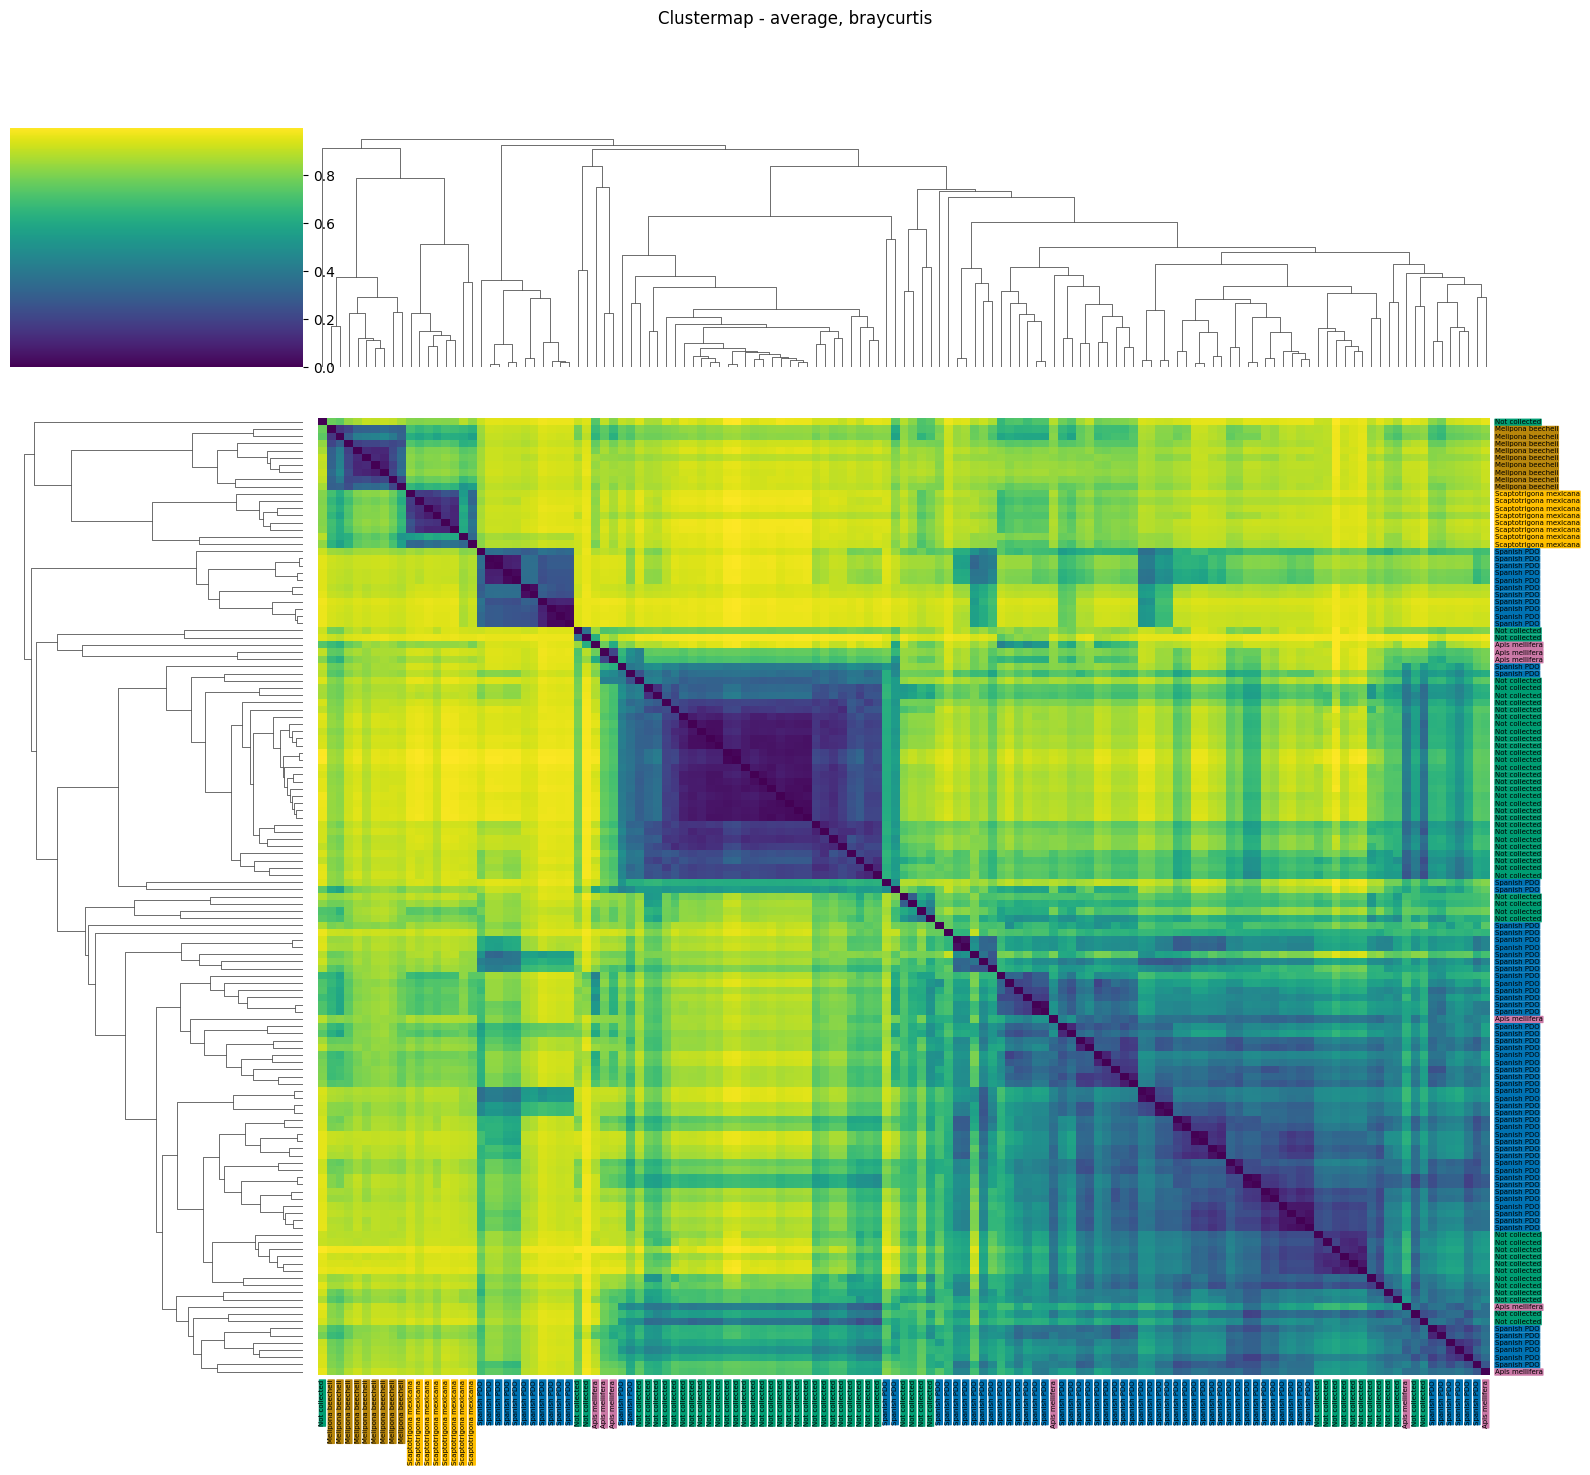

In [31]:
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

hierarchical_cluster_modif1(
    biom_tfidf,
    link='average',
    labels=labels_data,
    plot_dist_matrix=True,
    metric_d='braycurtis',
    palette=palette
)


In [48]:
def hierarchical_cluster_modif(X, link='ward', labels=None, plot_dist_matrix=True,
                                metric_d='euclidean', palette=None, filename='clustermap_output'):
    """
    Clustermap or dendrogram with row/column color bars instead of tick labels.
    Includes a legend mapping colors to bee species.

    Parameters
    ----------
    filename : str
        Base name for saved output files (without extension).
    """
    from scipy.cluster.hierarchy import linkage, dendrogram
    from scipy.spatial.distance import pdist, squareform
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    from matplotlib.patches import Patch

    def get_distance_matrix(X, metric='euclidean'):
        return squareform(pdist(X, metric=metric))

    link_mat = linkage(X, method=link, metric=metric_d)

    if plot_dist_matrix:
        dd = get_distance_matrix(X, metric=metric_d)

        # Mapear colores
        if labels is not None and palette is not None:
            labels = labels.loc[X.index] if isinstance(labels, pd.Series) else labels
            label_colors = pd.Series(labels).map(palette).to_numpy()
            row_colors = label_colors
            col_colors = label_colors
        else:
            row_colors = None
            col_colors = None

        # Clustermap
        g = sns.clustermap(
            dd,
            row_linkage=link_mat,
            col_linkage=link_mat,
            row_colors=row_colors,
            col_colors=col_colors,
            xticklabels=False,
            yticklabels=False,
            cmap="viridis",
            figsize=(14, 12)
        )

        # Leyenda personalizada
        if palette is not None:
            handles = [Patch(facecolor=col, label=lab) for lab, col in palette.items()]
            g.ax_heatmap.legend(
                handles=handles,
                title="Bee species",
                bbox_to_anchor=(1.05, 1),
                loc='upper left',
                borderaxespad=0.
            )

        plt.suptitle(f"Clustermap - {link}, {metric_d}", y=1.05)
        plt.tight_layout()
        g.savefig(f"../cabana/images/{filename}.png", dpi=300)
        g.savefig(f"../cabana/images/{filename}.svg")
        plt.show()

    else:
        plt.figure(figsize=(10, 5))
        dendrogram(
            link_mat,
            orientation='top',
            labels=labels,
            distance_sort='descending',
            show_leaf_counts=True
        )
        plt.title('Hierarchical Clustering Dendrogram')
        plt.xlabel('Data Points')
        plt.ylabel('Distance')
        plt.tight_layout()
        plt.savefig(f"../cabana/images/{filename}.png", dpi=300)
        plt.savefig(f"../cabana/images/{filename}.svg")
        plt.show()



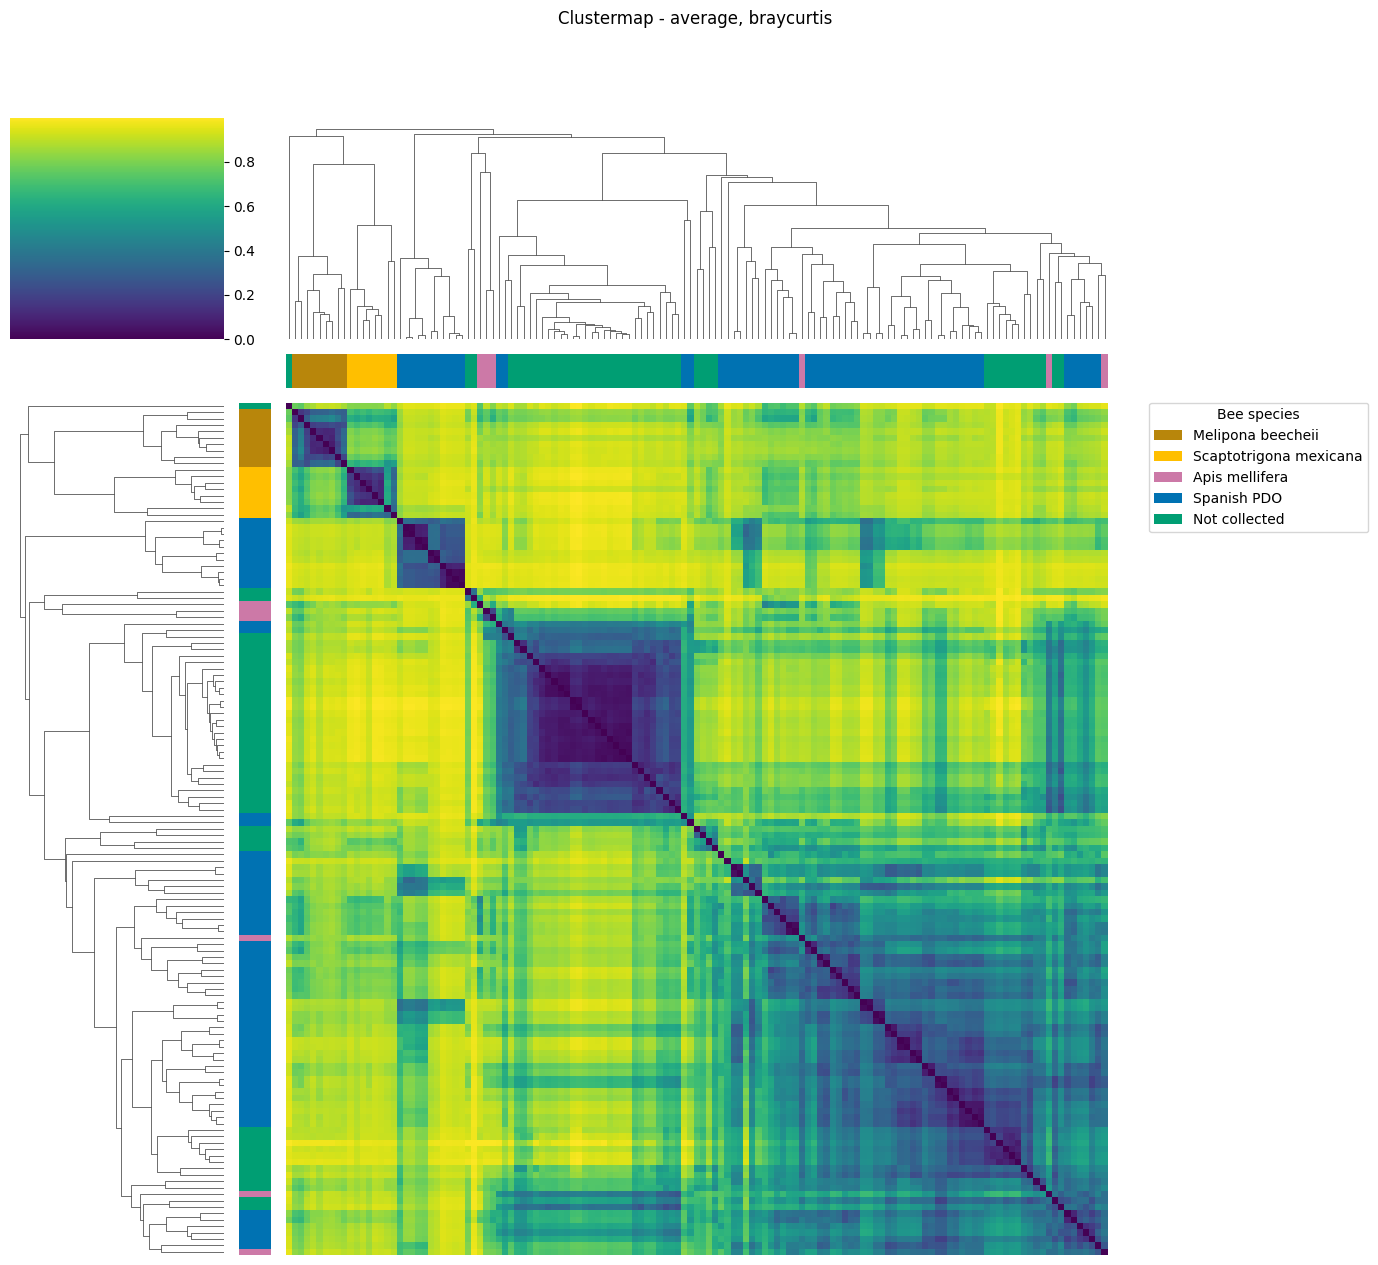

In [49]:
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

hierarchical_cluster_modif(
    biom_tfidf,
    link='average',
    labels=labels_data,
    plot_dist_matrix=True,
    metric_d='braycurtis',
    palette=palette, filename="clustermap_average_bray"
)


We can use hierarchical clustering with a vector representation of `biom` obtained with some dimention reduction technique from Chapter 3

In [50]:
dir_fact = '../cabana/models/'
n_comp = 50
exfact = True
nf = 'svd_tfidf'
fact_svd = get_lsa(biom_tfidf, exist_fact = exfact, fact_path = dir_fact, n_file = nf, n_comp = n_comp, save=True)

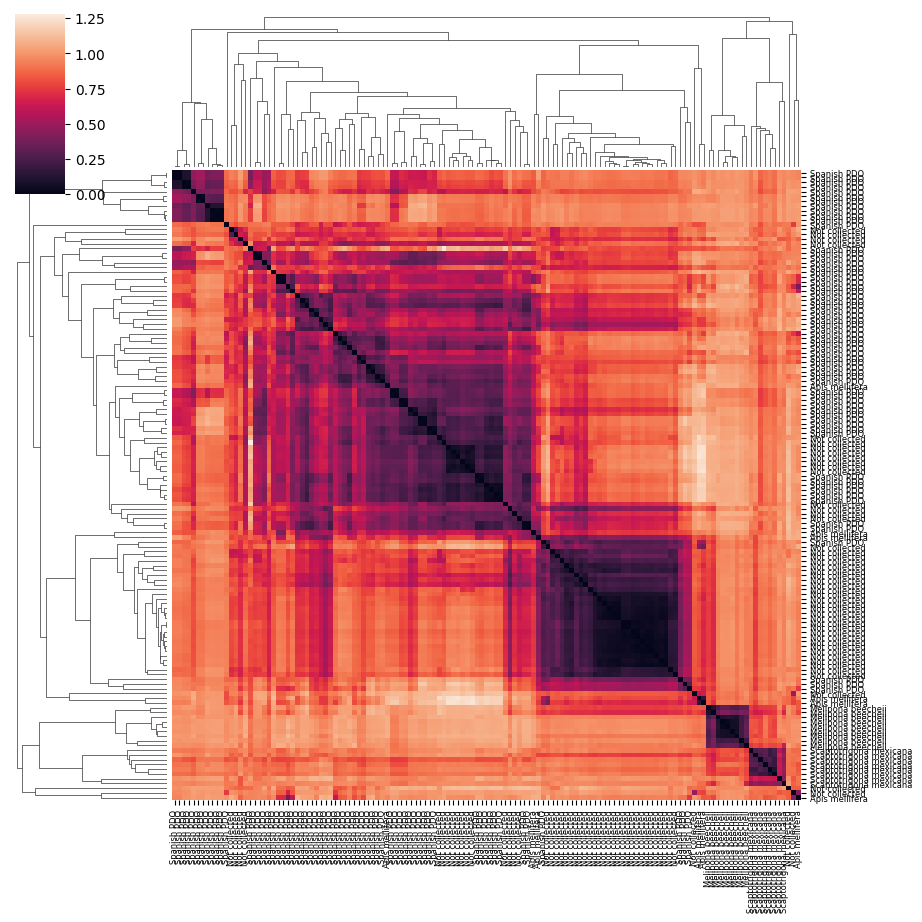

In [52]:
lk = 'average' #'single' 'complete' 'average' 'ward'
metric = 'braycurtis' # 'braycurtis' 'cosine'
hierarchical_cluster(fact_svd, link = lk, labels = labels_data,
                     plot_dist_matrix = True, metric_d = metric)

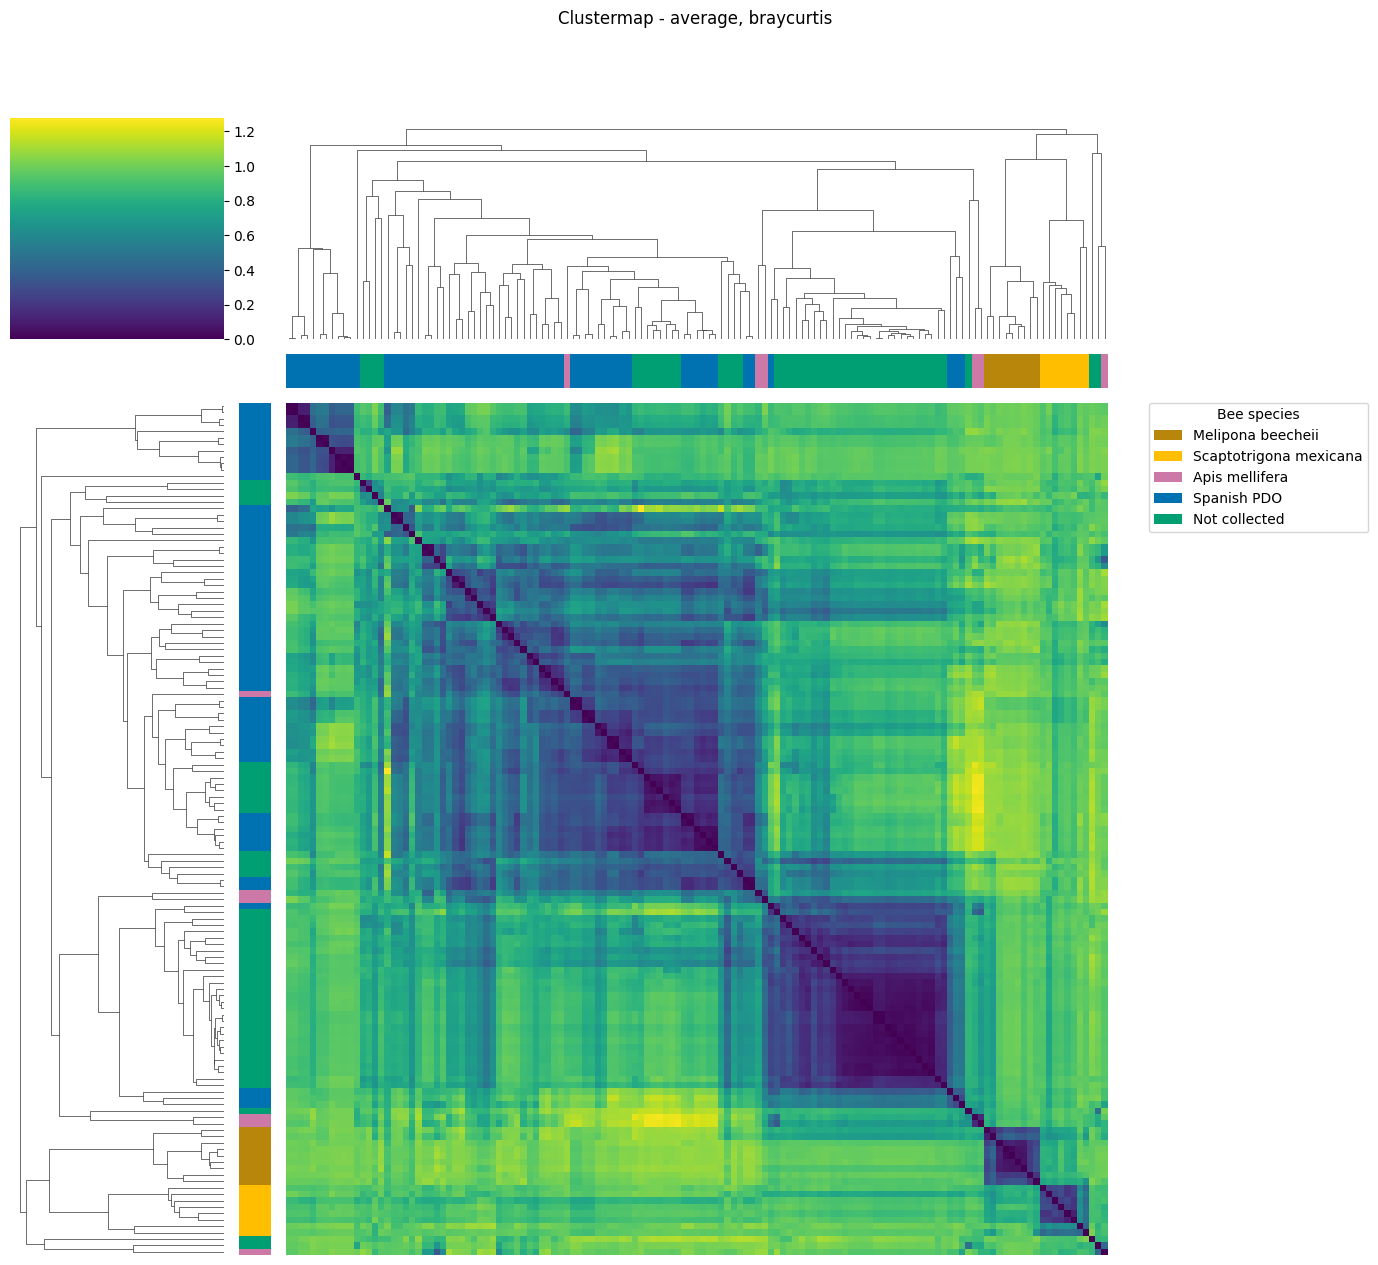

In [53]:
palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

hierarchical_cluster_modif(
    fact_svd,
    link='average',
    labels=labels_data,
    plot_dist_matrix=True,
    metric_d='braycurtis',
    palette=palette, filename="clustermap_average_bray_svd"
)

## K-means (15 min - 11:15 am)

This algorithm, partitions data into $k$ clusters (see Figure 3) by minimizing within (or intra) cluster variance (Figure 2).

![Inter and intra cluster distance](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*FbPP5TvWtA2yQ14xxsRWvQ.gif)

Figure 2. Inter and intra cluster distance.

![Inter and intra cluster distance](https://dashee87.github.io/images/kmeans.gif)

Figure 3. $k-$means procedure.

$K-$ means uses **euclidean distance** between data, so it would not be the best choice for high-dimensional data due to the [curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality), then, we will use some of the reduced dimensionality representation we obtained in Chapter 3.

### Factorization-based dimension reduction

In [54]:
labels_data.unique()

array(['Spanish PDO', 'Apis mellifera', 'Not collected',
       'Melipona beecheii', 'Scaptotrigona mexicana'], dtype=object)

In [55]:
from sklearn.cluster import KMeans, MiniBatchKMeans
X = fact_svd
nclust = len(labels_data.unique())
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)
#y_km = y_km.astype('category')

In [56]:
embedding = fact_svd
reduced_proj = pd.DataFrame({'x1': embedding.iloc[:,0], 'x2': embedding.iloc[:,1], 'label': labels_data,
                            'clust': [str(val) for val in y_km]})
reduced_proj['clust'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', hover_data='label', color = 'clust', title='reduced plot')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

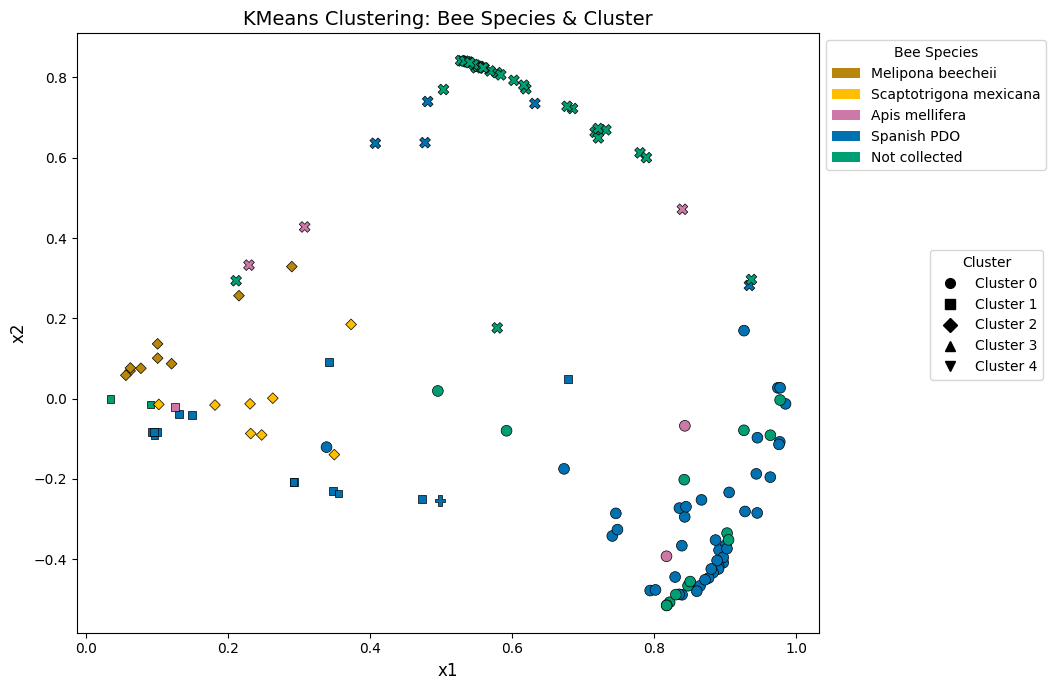

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# === Datos base ===
X = fact_svd
nclust = len(labels_data.unique())
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)

# Crear DataFrame
reduced_proj = pd.DataFrame({
    'x1': X.iloc[:, 0],
    'x2': X.iloc[:, 1],
    'label': labels_data,
    'clust': [str(val) for val in y_km]
}, index=X.index)

# Paleta fija de especies
species_palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# Crear el plot
plt.figure(figsize=(13, 7))
sns.scatterplot(
    data=reduced_proj,
    x='x1', y='x2',
    hue='label',
    style='clust',
    palette=species_palette,
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.title("KMeans Clustering: Bee Species & Cluster", fontsize=14)
plt.xlabel("x1", fontsize=12)
plt.ylabel("x2", fontsize=12)

# === Leyenda 1: Bee species (colores) ===
handles_species = [
    Patch(facecolor=color, label=label)
    for label, color in species_palette.items()
]

# === Leyenda 2: Cluster (formas, ordenada) ===
style_markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
clusters_sorted = sorted(reduced_proj['clust'].unique(), key=lambda x: int(x))
handles_cluster = [
    Line2D([0], [0], marker=style_markers[int(cl)], color='black',
           label=f"Cluster {cl}", markersize=7, linestyle='None')
    for cl in clusters_sorted
]

# Posicionar ambas leyendas una debajo de otra
legend1 = plt.legend(handles=handles_species, title="Bee Species",
                     bbox_to_anchor=(1, 1), loc='upper left')
plt.gca().add_artist(legend1)  # Necesario para que no se sobrescriba

plt.legend(handles=handles_cluster, title="Cluster",
           bbox_to_anchor=(1.14, 0.65), loc='upper left')

plt.subplots_adjust(right=2)  # dejar más espacio al lado derecho
plt.tight_layout()

# Guardar
plt.savefig("../cabana/images/kmeans_species_cluster_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("../cabana/images/kmeans_species_cluster_plot.svg", format="svg", bbox_inches='tight')
plt.show()


### Manifold learning methods

In [78]:
import umap.umap_ as umap

reducer = umap.UMAP(n_neighbors=5, n_components=2, min_dist=.2, metric='braycurtis', random_state=42)
embedding = reducer.fit_transform(biom_tfidf)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [79]:
X = embedding
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)
#y_km = y_km.astype('category')

In [80]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data,
                            'cluster': [str(val) for val in y_km]})
#reduced_proj['cluster'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', hover_data='label', color = 'cluster', title='UMAP')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



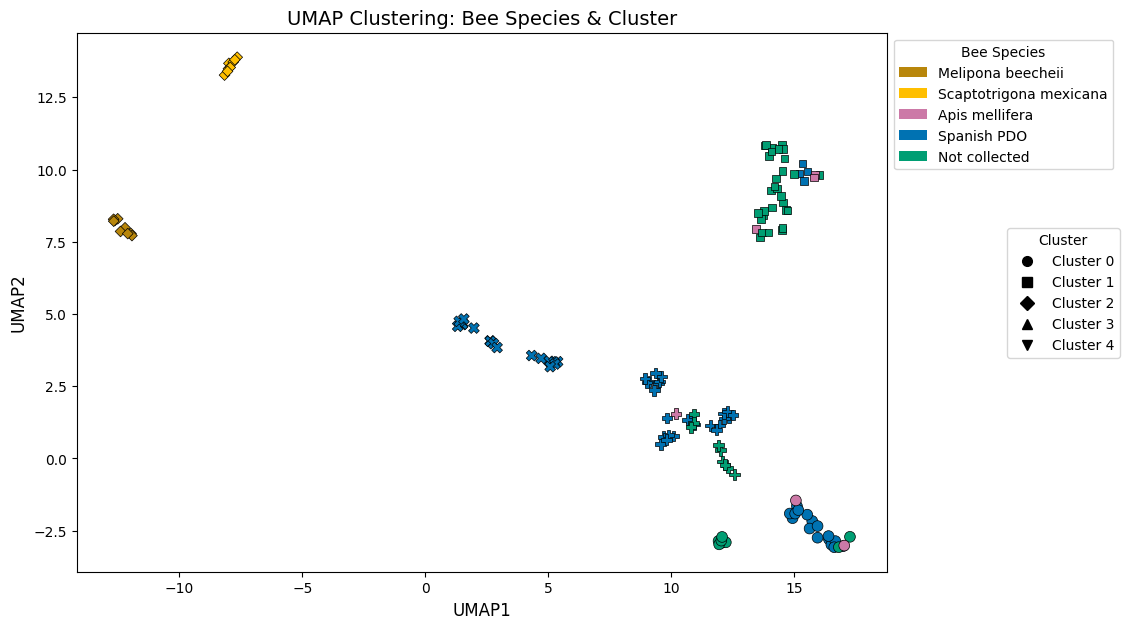

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# === Datos base ===
reducer = umap.UMAP(n_neighbors=5, n_components=2, min_dist=.2, metric='braycurtis', random_state=42)
embedding = reducer.fit_transform(biom_tfidf)
X = embedding
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)

# Crear DataFrame
reduced_proj = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'label': labels_data,
    'cluster': [str(val) for val in y_km]
})

# Paleta fija por especie
species_palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# === Plot ===
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=reduced_proj,
    x='x1', y='x2',
    hue='label',              # color por especie
    style='cluster',          # forma por clúster
    palette=species_palette,
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.title("UMAP Clustering: Bee Species & Cluster", fontsize=14)
plt.xlabel("UMAP1", fontsize=12)
plt.ylabel("UMAP2", fontsize=12)

# === Leyenda de especies (color)
handles_species = [
    Patch(facecolor=color, label=label)
    for label, color in species_palette.items()
]

# === Leyenda de clústeres (forma), ordenada
style_markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
clusters_sorted = sorted(reduced_proj['cluster'].unique(), key=lambda x: int(x))
handles_cluster = [
    Line2D([0], [0], marker=style_markers[int(cl)], color='black',
           label=f"Cluster {cl}", markersize=7, linestyle='None')
    for cl in clusters_sorted
]

# === Posicionar leyendas
legend1 = plt.legend(handles=handles_species, title="Bee Species",
                     bbox_to_anchor=(1, 1), loc='upper left')
plt.gca().add_artist(legend1)

plt.legend(handles=handles_cluster, title="Cluster",
           bbox_to_anchor=(1.14, 0.65), loc='upper left')

# Ajustar layout para que no se corte
plt.subplots_adjust(right=0.8)

# Guardar como imagen
plt.savefig("../cabana/images/umap_species_cluster_plot.png", dpi=300)
plt.savefig("../cabana/images/umap_species_cluster_plot.svg", format="svg")
plt.show()


### Distance-based + dimension reduction, representations

In [84]:
d_matrix = get_distance_matrix(biom_tfidf, 'braycurtis')
#d_matrix.isna().any().any()
#d_matrix = np.round(d_matrix,5)

Dimension reduction

In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA

pca = PCA(n_components=3)
embedding = pca.fit_transform(d_matrix)

X = embedding
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)
#y_km = y_km.astype('category')

In [86]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data,
                            'cluster': [str(val) for val in y_km]})
#reduced_proj['cluster'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', hover_data='label', color = 'cluster', title='PCA')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

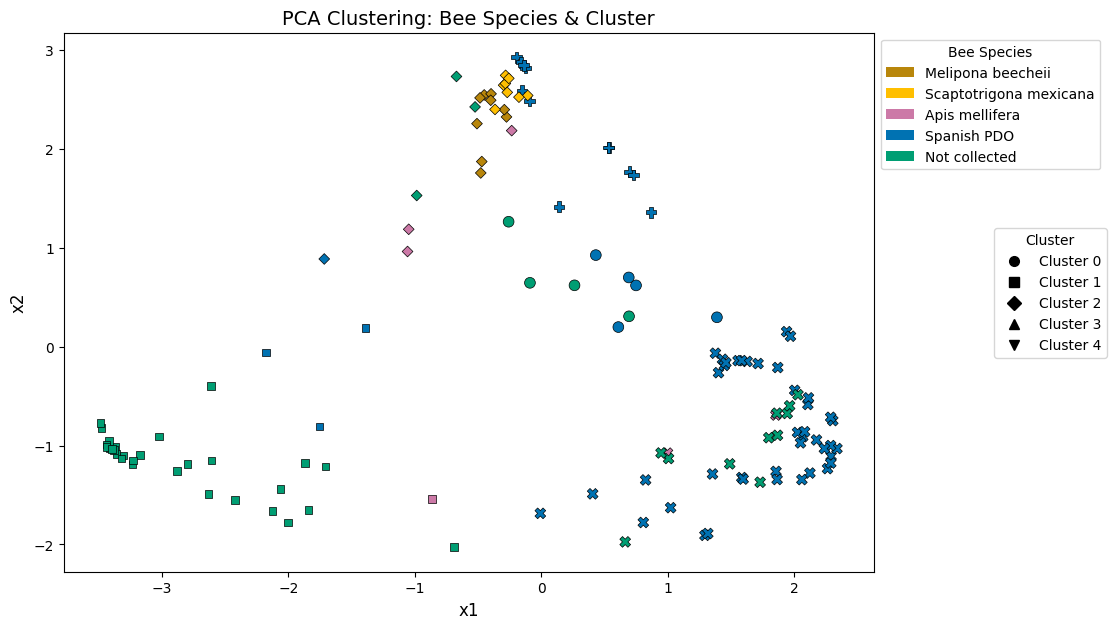

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# === Datos base ===
pca = PCA(n_components=3)
embedding = pca.fit_transform(d_matrix)

X = embedding
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)

# Crear DataFrame
reduced_proj = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'label': labels_data,
    'cluster': [str(val) for val in y_km]
})

# Paleta fija por especie
species_palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# === Plot ===
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=reduced_proj,
    x='x1', y='x2',
    hue='label',              # color por especie
    style='cluster',          # forma por clúster
    palette=species_palette,
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.title("PCA Clustering: Bee Species & Cluster", fontsize=14)
plt.xlabel("x1", fontsize=12)
plt.ylabel("x2", fontsize=12)

# === Leyenda de especies (color)
handles_species = [
    Patch(facecolor=color, label=label)
    for label, color in species_palette.items()
]

# === Leyenda de clústeres (forma), ordenada
style_markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
clusters_sorted = sorted(reduced_proj['cluster'].unique(), key=lambda x: int(x))
handles_cluster = [
    Line2D([0], [0], marker=style_markers[int(cl)], color='black',
           label=f"Cluster {cl}", markersize=7, linestyle='None')
    for cl in clusters_sorted
]

# === Posicionar leyendas
legend1 = plt.legend(handles=handles_species, title="Bee Species",
                     bbox_to_anchor=(1, 1), loc='upper left')
plt.gca().add_artist(legend1)

plt.legend(handles=handles_cluster, title="Cluster",
           bbox_to_anchor=(1.14, 0.65), loc='upper left')

# Ajustar layout para que no se corte
plt.subplots_adjust(right=0.8)

# Guardar como imagen
plt.savefig("../cabana/images/pca_species_cluster_plot.png", dpi=300)
plt.savefig("../cabana/images/pca_species_cluster_plot.svg", format="svg")
plt.show()

In [88]:
from sklearn.manifold import MDS

nmds = MDS(n_components=3, dissimilarity='precomputed', metric=False, random_state=42)
embedding = nmds.fit_transform(d_matrix)

X = embedding
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)
#y_km = y_km.astype('category')

In [89]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data,
                            'cluster': [str(val) for val in y_km]})
#reduced_proj['cluster'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', hover_data='label', color = 'cluster', title='non-metric MDS')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

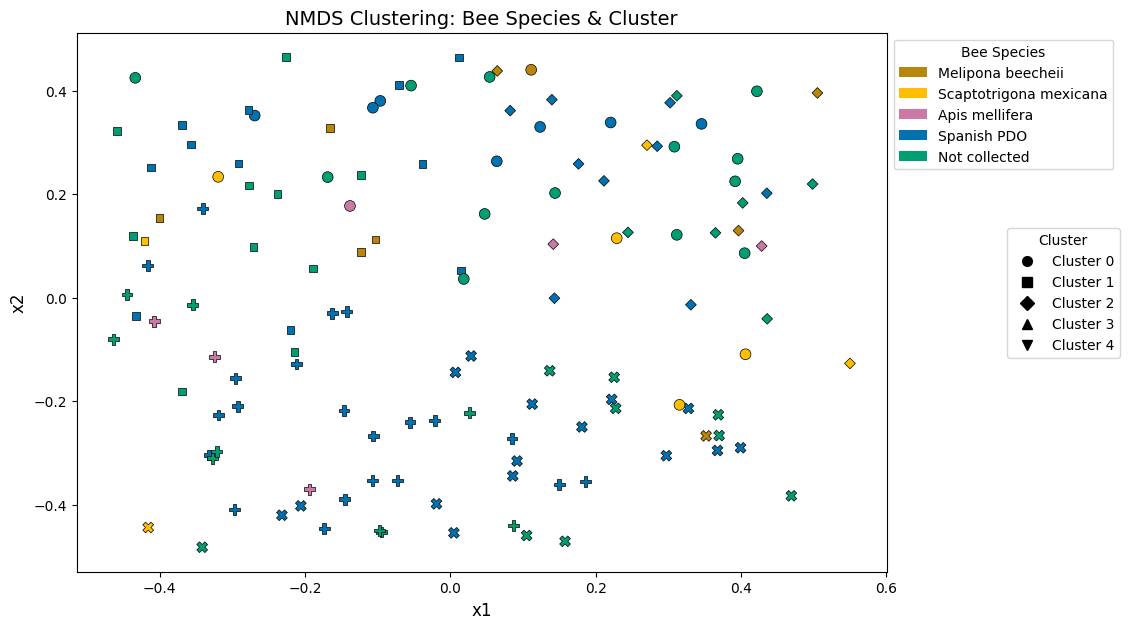

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# === Datos base ===
nmds = MDS(n_components=3, dissimilarity='precomputed', metric=False, random_state=42)
embedding = nmds.fit_transform(d_matrix)

X = embedding
kmeans = KMeans(n_clusters=nclust, init='k-means++', n_init='auto', random_state=42)
y_km = kmeans.fit_predict(X)

# Crear DataFrame
reduced_proj = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'label': labels_data,
    'cluster': [str(val) for val in y_km]
})

# Paleta fija por especie
species_palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# === Plot ===
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=reduced_proj,
    x='x1', y='x2',
    hue='label',              # color por especie
    style='cluster',          # forma por clúster
    palette=species_palette,
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.title("NMDS Clustering: Bee Species & Cluster", fontsize=14)
plt.xlabel("x1", fontsize=12)
plt.ylabel("x2", fontsize=12)

# === Leyenda de especies (color)
handles_species = [
    Patch(facecolor=color, label=label)
    for label, color in species_palette.items()
]

# === Leyenda de clústeres (forma), ordenada
style_markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
clusters_sorted = sorted(reduced_proj['cluster'].unique(), key=lambda x: int(x))
handles_cluster = [
    Line2D([0], [0], marker=style_markers[int(cl)], color='black',
           label=f"Cluster {cl}", markersize=7, linestyle='None')
    for cl in clusters_sorted
]

# === Posicionar leyendas
legend1 = plt.legend(handles=handles_species, title="Bee Species",
                     bbox_to_anchor=(1, 1), loc='upper left')
plt.gca().add_artist(legend1)

plt.legend(handles=handles_cluster, title="Cluster",
           bbox_to_anchor=(1.14, 0.65), loc='upper left')

# Ajustar layout para que no se corte
plt.subplots_adjust(right=0.8)

# Guardar como imagen
plt.savefig("../cabana/images/nmds_species_cluster_plot.png", dpi=300)
plt.savefig("../cabana/images/nmds_species_cluster_plot.svg", format="svg")
plt.show()

## DBSCAN (10 min - 11:30 am)

DBSCAN (**Density-Based** Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups data points based on their proximity and density.

The methodology involves randomly pick points which could start a cluster depending on the density of data around it, then, expands the cluster by adding all reachable points within some neighborhood $\epsilon$. The steps are repeated for unvisited points until all points are processed. See Figure 4 for an illustration.



![DBSCAN](https://dashee87.github.io/images/DBSCAN_tutorial.gif)

Figure 4. DBSCAN procedure.

In [91]:
from sklearn.cluster import DBSCAN

reducer = umap.UMAP(n_neighbors=5, n_components=2, min_dist=.12, metric='braycurtis',
                    random_state=42)
embedding = reducer.fit_transform(biom_tfidf)
X = embedding

dbscan = DBSCAN(eps=0.8, min_samples=5, metric='euclidean')
y_db = dbscan.fit_predict(X)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [92]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data,
                            'cluster': [str(val) for val in y_db]})
#reduced_proj['cluster'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', hover_data='label', color = 'cluster', title='UMAP')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



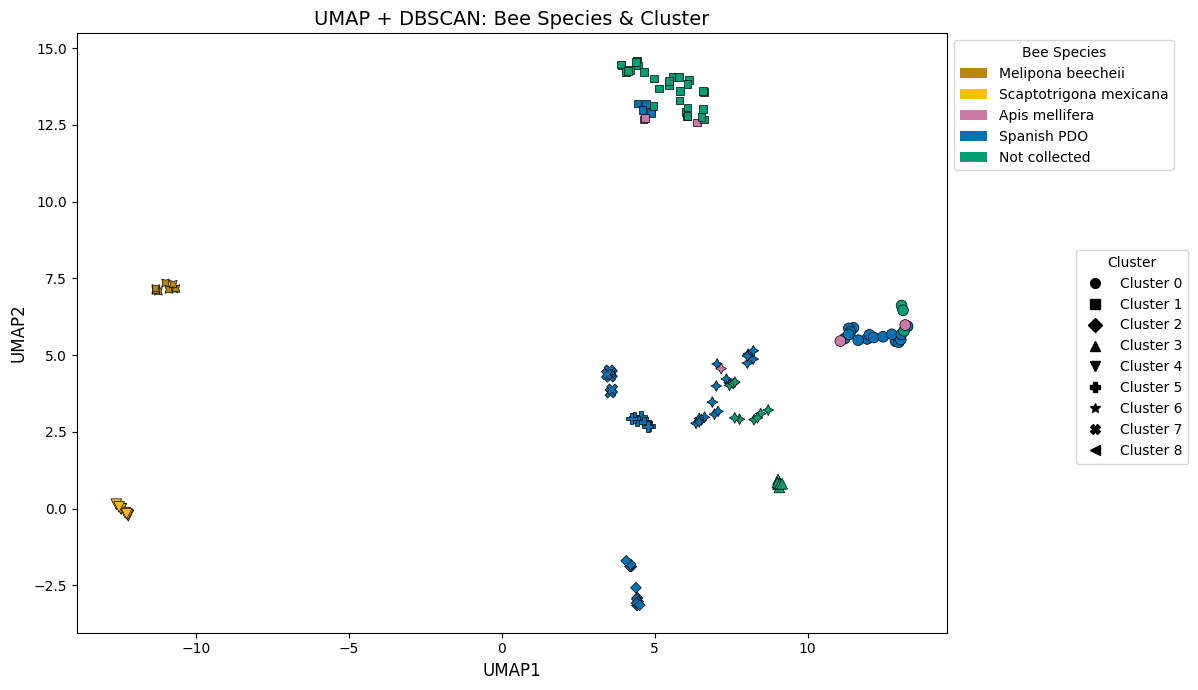

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
import umap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# === UMAP reducción ===
reducer = umap.UMAP(n_neighbors=5, n_components=2, min_dist=.12, metric='braycurtis', random_state=42)
embedding = reducer.fit_transform(biom_tfidf)
X = embedding

# === DBSCAN clustering ===
dbscan = DBSCAN(eps=0.8, min_samples=5, metric='euclidean')
y_db = dbscan.fit_predict(X)  # -1 indica ruido

# Crear DataFrame
reduced_proj = pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'label': labels_data,
    'cluster': [str(val) if val != -1 else "Noise" for val in y_db]
})

# Paleta de colores para especies
species_palette = {
    "Melipona beecheii": "#b8860b",
    "Scaptotrigona mexicana": "#FFBF00",
    "Apis mellifera": "#CC79A7",
    "Spanish PDO": "#0072B2",
    "Not collected": "#009E73"
}

# === Plot ===
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=reduced_proj,
    x='x1', y='x2',
    hue='label',
    style='cluster',
    palette=species_palette,
    s=60,
    edgecolor='black',
    linewidth=0.5
)

plt.title("UMAP + DBSCAN: Bee Species & Cluster", fontsize=14)
plt.xlabel("UMAP1", fontsize=12)
plt.ylabel("UMAP2", fontsize=12)

# === Leyenda 1: Bee species (color)
handles_species = [
    Patch(facecolor=color, label=label)
    for label, color in species_palette.items()
]

# === Leyenda 2: DBSCAN cluster (forma)
# Incluye "Noise" y ordena numéricamente (con Noise al final)
style_markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', '<', '>']
clusters = reduced_proj['cluster'].unique()
clusters_ordered = sorted([cl for cl in clusters if cl != "Noise"], key=int) + (["Noise"] if "Noise" in clusters else [])

handles_cluster = [
    Line2D([0], [0], marker=style_markers[i % len(style_markers)], color='black',
           label=f"Cluster {cl}" if cl != "Noise" else "Noise",
           markersize=7, linestyle='None')
    for i, cl in enumerate(clusters_ordered)
]

# === Agregar leyendas
legend1 = plt.legend(handles=handles_species, title="Bee Species",
                     bbox_to_anchor=(1, 1), loc='upper left')
plt.gca().add_artist(legend1)

plt.legend(handles=handles_cluster, title="Cluster",
           bbox_to_anchor=(1.14, 0.65), loc='upper left')

# Ajustes finales
plt.subplots_adjust(right=0.8)
plt.tight_layout()

# Guardar
plt.savefig("../cabana/images/umap_dbscan_species_cluster_plot.png", dpi=300)
plt.savefig("../cabana/images/umap_dbscan_species_cluster_plot.svg", format="svg")
plt.show()


In [95]:
pca = PCA(n_components=3)
embedding = pca.fit_transform(d_matrix)
X = embedding

# Use PCA coordinates from above
dbscan = DBSCAN(eps=0.3, min_samples=3, metric='euclidean')
y_db = dbscan.fit_predict(X)

In [96]:
reduced_proj = pd.DataFrame({'x1': embedding[:,0], 'x2': embedding[:,1], 'label': labels_data,
                            'cluster': [str(val) for val in y_db]})
#reduced_proj['cluster'].astype('category')
fig = px.scatter(reduced_proj, x='x1', y='x2', hover_data='label', color = 'cluster', title='PCA')
fig.update_layout(autosize=False, width=500, height=500)
fig.show()

### Exercise # 4.1 Clusetring with Jaccard metric

In [ ]:
# Binarize dataframe (presence/absence)
biom_df_binary = (biom_df > 0).astype(int)
biom_df_binary


,G000005825,G000006175,G000006605,G000006725,G000006745,G000006785,G000006845,G000006865,G000006925,G000006965,...,G902812375,G902812395,G902825795,G902825845,G902825965,G902826025,G902826465,G902826605,G902827015,G902827055
13114.jensen.43.s012,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
13114.jensen.43.s013,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
13114.jensen.43.s014,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
13114.pinto.63.s001,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
13114.pinto.63.s002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13114.zaneveld.9.s006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13114.zaneveld.9.s010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13114.zaneveld.9.s011,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13114.zaneveld.9.s012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Computes Jaccard distance

In [ ]:
jaccard_dm = beta_diversity("jaccard", biom_df_binary)
jaccard_df = jaccard_dm.to_data_frame()
jaccard_df

,13114.jensen.43.s012,13114.jensen.43.s013,13114.jensen.43.s014,13114.pinto.63.s001,13114.pinto.63.s002,13114.pinto.63.s003,13114.pinto.63.s004,13114.pinto.63.s005,13114.pinto.63.s006,13114.pinto.63.s007,...,13114.stewart.26.s006,13114.stewart.26.s007,13114.stewart.26.s008,13114.zaneveld.9.s004,13114.zaneveld.9.s005,13114.zaneveld.9.s006,13114.zaneveld.9.s010,13114.zaneveld.9.s011,13114.zaneveld.9.s012,13114.zaneveld.9.s022
13114.jensen.43.s012,0.000000,0.685239,0.842507,0.935381,0.926755,0.927890,0.913415,0.927083,0.926444,0.914347,...,0.854079,0.759064,0.821874,0.889849,0.894593,0.895279,0.923993,0.952989,0.921440,0.706720
13114.jensen.43.s013,0.685239,0.000000,0.798991,0.946271,0.942408,0.955083,0.937202,0.951576,0.946809,0.948698,...,0.837468,0.814600,0.839612,0.893409,0.897010,0.893476,0.930543,0.960600,0.921717,0.791247
13114.jensen.43.s014,0.842507,0.798991,0.000000,0.903226,0.915601,0.883994,0.915612,0.911323,0.933142,0.896254,...,0.930779,0.912212,0.927369,0.857554,0.843703,0.856721,0.878092,0.926733,0.881064,0.902861
13114.pinto.63.s001,0.935381,0.946271,0.903226,0.000000,0.635688,0.689655,0.672727,0.645545,0.700777,0.652893,...,0.966752,0.944322,0.961296,0.779174,0.760994,0.768657,0.756563,0.763006,0.758264,0.945783
13114.pinto.63.s002,0.926755,0.942408,0.915601,0.635688,0.000000,0.766942,0.699313,0.727273,0.697757,0.716724,...,0.971839,0.947569,0.964301,0.819970,0.808917,0.805031,0.794175,0.810811,0.803754,0.945838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13114.zaneveld.9.s006,0.895279,0.893476,0.856721,0.768657,0.805031,0.778182,0.795414,0.800676,0.855395,0.782765,...,0.950128,0.919946,0.938126,0.550308,0.525164,0.000000,0.662592,0.752747,0.677215,0.902098
13114.zaneveld.9.s010,0.923993,0.930543,0.878092,0.756563,0.794175,0.777523,0.782998,0.795359,0.871990,0.783296,...,0.965588,0.946296,0.959222,0.659574,0.628205,0.662592,0.000000,0.561644,0.538922,0.936684
13114.zaneveld.9.s011,0.952989,0.960600,0.926733,0.763006,0.810811,0.753541,0.754144,0.789873,0.877465,0.788043,...,0.979740,0.960476,0.976132,0.765625,0.737143,0.752747,0.561644,0.000000,0.665541,0.961985
13114.zaneveld.9.s012,0.921440,0.921717,0.881064,0.758264,0.803754,0.756592,0.766798,0.789963,0.849348,0.783890,...,0.964683,0.935863,0.955464,0.657676,0.648352,0.677215,0.538922,0.665541,0.000000,0.926271


/content/drive/.shortcut-targets-by-id/1eKs0tfWS-cK-e7yEJDo_SBtQTO6Qv6NR/Module 2 Clustering/2. Notebooks_Latam/aux_functions.py:535: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



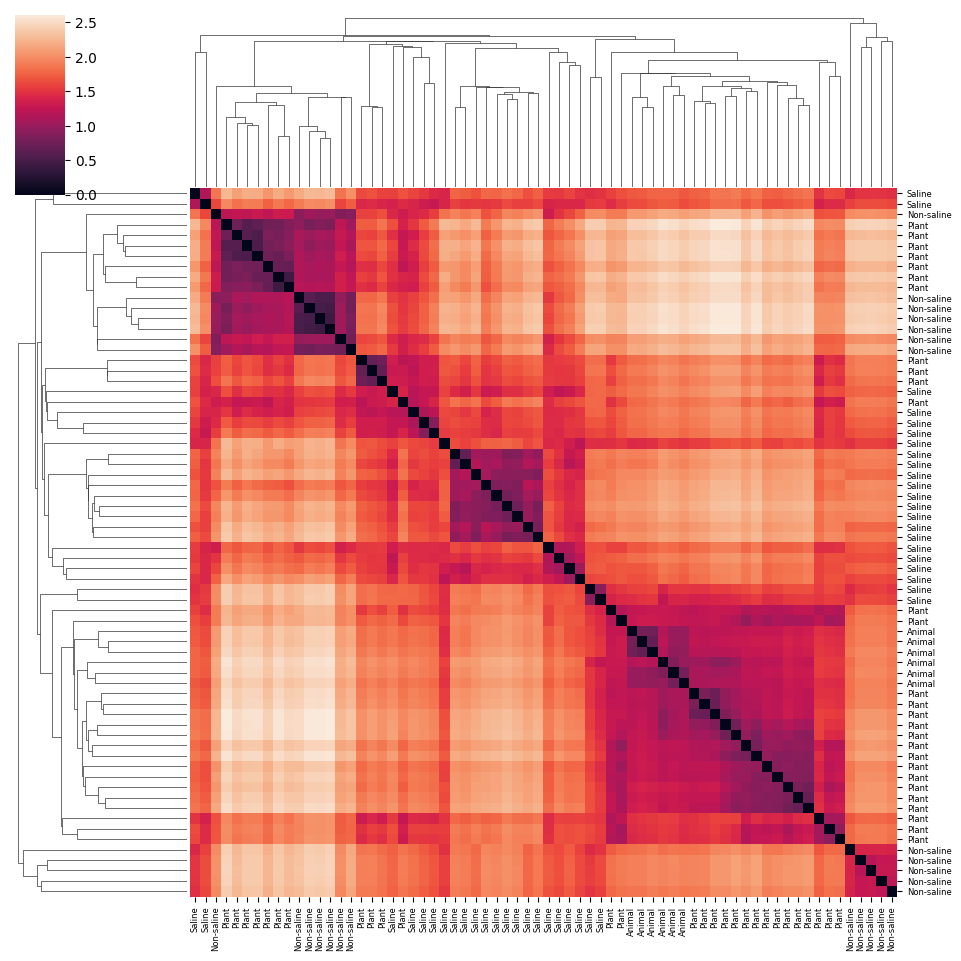

In [ ]:
lk = 'single' #'single' 'complete' 'average' 'ward'
metric = 'euclidean' #'euclidean' 'braycurtis' 'cosine'
hierarchical_cluster(jaccard_df, link = lk, labels = labels_data,
                     plot_dist_matrix = True, metric_d = metric)

## Self evaluation poll (10 min - 11:40 am)

This short assessment will help reinforce your understanding and prepare you for further analysis and integration tasks in microbiome research.

📌 Click the link below to begin the quiz: 👉  [Poll link, Quiz 4](https://pollev.com/biotrainaicabana135)

1. Select “**Skip for now**” when prompted to log in.

2. Enter **your name** to join as a participant.

3. **Select all correct answers** — some questions may have multiple correct options.

4. You can review your **results** at the end of the quiz.


## Evaluation of second morning session ( 3 min - 11:50 am)

Please complete the session evaluation by filling out the following form: [Evaluation of second morning sesion](https://docs.google.com/forms/d/e/1FAIpQLSctmNOXjAtp-1sSKCgBKlT2L_iCVnFzuY_ohKESJ2_A7XvrMw/viewform?usp=header)